### Hi-C example locus

In [10]:
ctrl = "/Zulu/bnolan/Projects/Personal/Ethanol/GEO/HiC/ctrl_merged_nodups_q30_592m.hic"
t1 = "/Zulu/bnolan/Projects/Personal/Ethanol/GEO/HiC/etoh_merged_nodups_q30_592m.hic"
t2 = "/Zulu/bnolan/Projects/Personal/Ethanol/GEO/HiC/T2_mega_q30.hic"
hics = [
    ctrl,
    t1,
    t2
]

In [17]:
import os
import hicstraw
import numpy as np
import matplotlib.pyplot as plt

os.path.exists(ctrl)

True

In [12]:
hicdump=hicstraw.HiCFile(ctrl)

In [13]:
subset_conditions = [
    {"name": "Ctl", "hic_path": hics[0], "idx": 0},
    {"name": "EtOH", "hic_path": hics[1], "idx": 1},
    {"name": "Withdraw", "hic_path": hics[2], "idx": 2},
]

### Locus

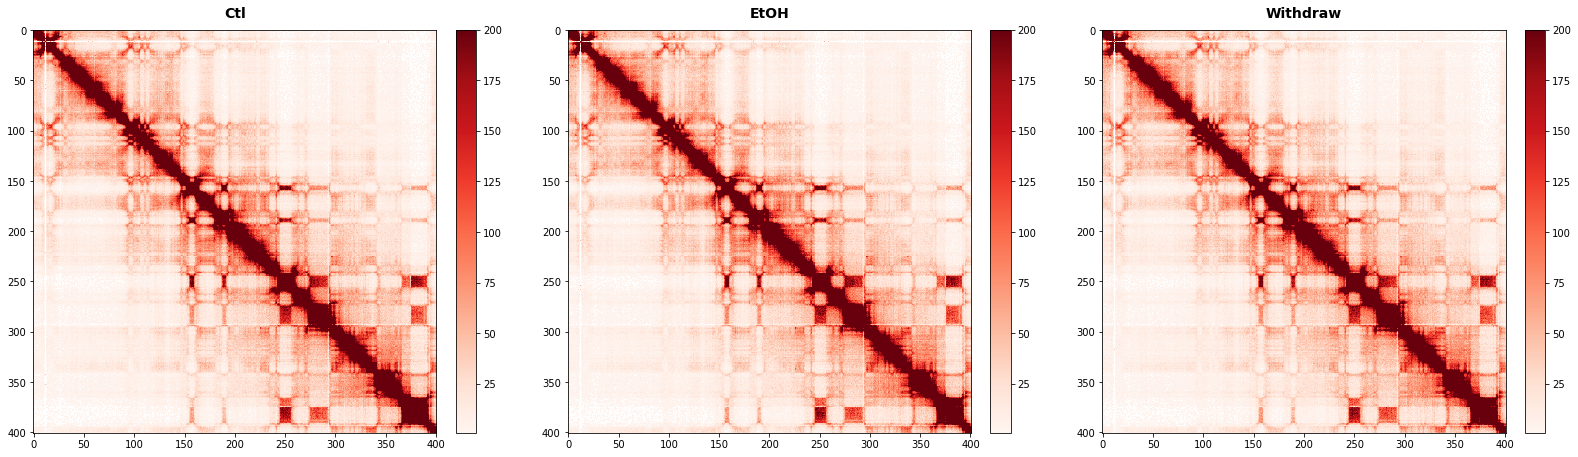

In [33]:
ceiling_value=200
cmap = "Reds"

chrom = "1"
start = 10_000_000
stop = 110_000_000
res = 250_000

# Extraction pass
matrices = []
for cond in subset_conditions:
    mp = cond["hic_path"]
    hicdump=hicstraw.HiCFile(mp)
    # Get the specific zoom data
    hicobject = hicdump.getMatrixZoomData(chrom, chrom, "o", "VC_SQRT", "BP", res)
    
    hiclist = hicobject.getRecords(start, stop, start, stop)

    size = int((stop-start)/res)
    mat = np.zeros((size+1, size+1))

    for cr in hiclist:
        r = int((cr.binX - start) / res)
        c = int((cr.binY - start) / res)
        mat[r,c] = cr.counts
        mat[c,r] = cr.counts
    
    # Clip matrix values at the defined ceiling threshold
    mat = np.clip(mat, a_min=0, a_max=ceiling_value)
    
    # Replace 0 with NaN for visualization if desired
    mat[mat == 0] = np.nan
    
    matrices.append(mat)

# Rendering pass
fig, axes = plt.subplots(ncols=3, figsize=(24, 8))
plt.rcParams["font.family"] = "sans-serif"
fig.subplots_adjust(top=0.85, bottom=0.15, left=0.05, right=0.95, wspace=0.1)

for idx, cond in enumerate(subset_conditions):
    ax = axes[idx]
    mat = matrices[idx]
    
    # Standard imshow for square matrix
    im = ax.imshow(
        mat, 
        cmap=cmap, 
        interpolation='none',
        origin='upper'
    )
    
    ax.set_title(cond["name"], fontsize=14, fontweight="bold", pad=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.axis('on') # Showing axes to confirm square structure
plt.savefig('largelocus_panelA.pdf')

### Loops loci

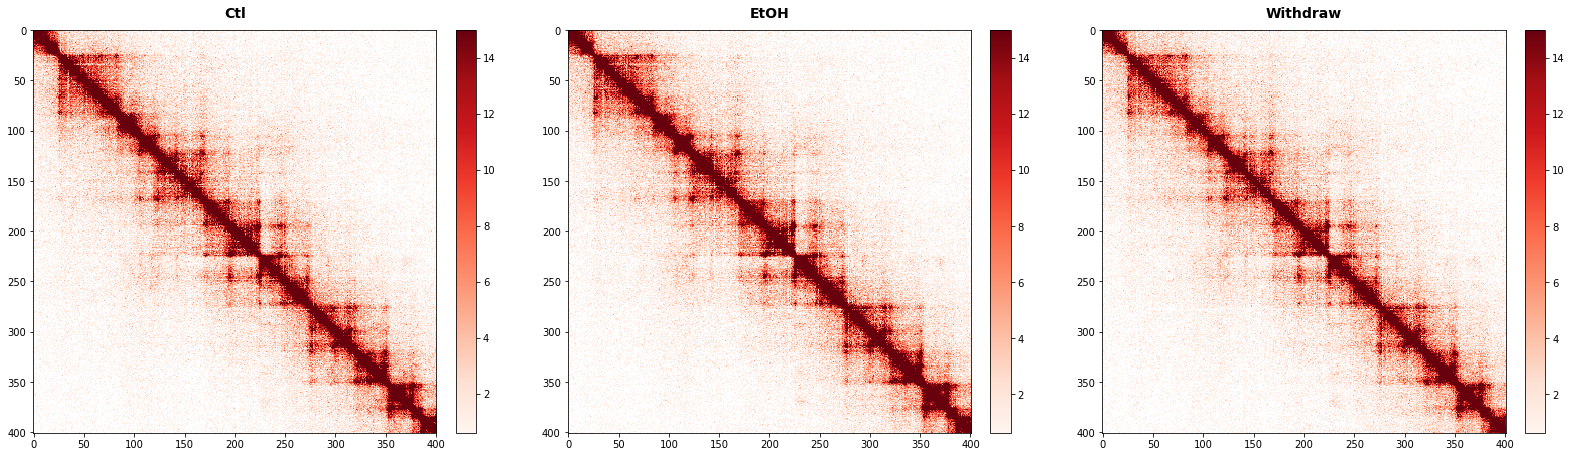

In [34]:
ceiling_value=15
cmap = "Reds"

chrom = "1"
start = 64_000_000
stop = 68_000_000
res = 10_000

# Extraction pass
matrices = []
for cond in subset_conditions:
    mp = cond["hic_path"]
    hicdump=hicstraw.HiCFile(mp)
    # Get the specific zoom data
    hicobject = hicdump.getMatrixZoomData(chrom, chrom, "o", "VC_SQRT", "BP", res)
    
    hiclist = hicobject.getRecords(start, stop, start, stop)

    size = int((stop-start)/res)
    mat = np.zeros((size+1, size+1))

    for cr in hiclist:
        r = int((cr.binX - start) / res)
        c = int((cr.binY - start) / res)
        mat[r,c] = cr.counts
        mat[c,r] = cr.counts
    
    # Clip matrix values at the defined ceiling threshold
    mat = np.clip(mat, a_min=0, a_max=ceiling_value)
    
    # Replace 0 with NaN for visualization if desired
    mat[mat == 0] = np.nan
    
    matrices.append(mat)

# Rendering pass
fig, axes = plt.subplots(ncols=3, figsize=(24, 8))
plt.rcParams["font.family"] = "sans-serif"
fig.subplots_adjust(top=0.85, bottom=0.15, left=0.05, right=0.95, wspace=0.1)

for idx, cond in enumerate(subset_conditions):
    ax = axes[idx]
    mat = matrices[idx]
    
    # Standard imshow for square matrix
    im = ax.imshow(
        mat, 
        cmap=cmap, 
        interpolation='none',
        origin='upper'
    )
    
    ax.set_title(cond["name"], fontsize=14, fontweight="bold", pad=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.axis('on') # Showing axes to confirm square structure
plt.savefig('looplocus_panelA.pdf')